<a href="https://colab.research.google.com/github/ScholarlyInsane/ml-practice/blob/main/LSTM%7CPart_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Long Short Term Memory networks – usually just called “LSTMs” – are a special kind of RNN, capable of learning long-term dependencies. They were introduced by Hochreiter & Schmidhuber (1997), and were refined and popularized by many people in following work.1 They work tremendously well on a large variety of problems, and are now widely used.

LSTMs are explicitly designed to avoid the long-term dependency problem. Remembering information for long periods of time is practically their default behavior, not something they struggle to learn !

X_train shape: (760, 50, 1)
y_train shape: (760,)

Training the LSTM model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model training complete.

24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


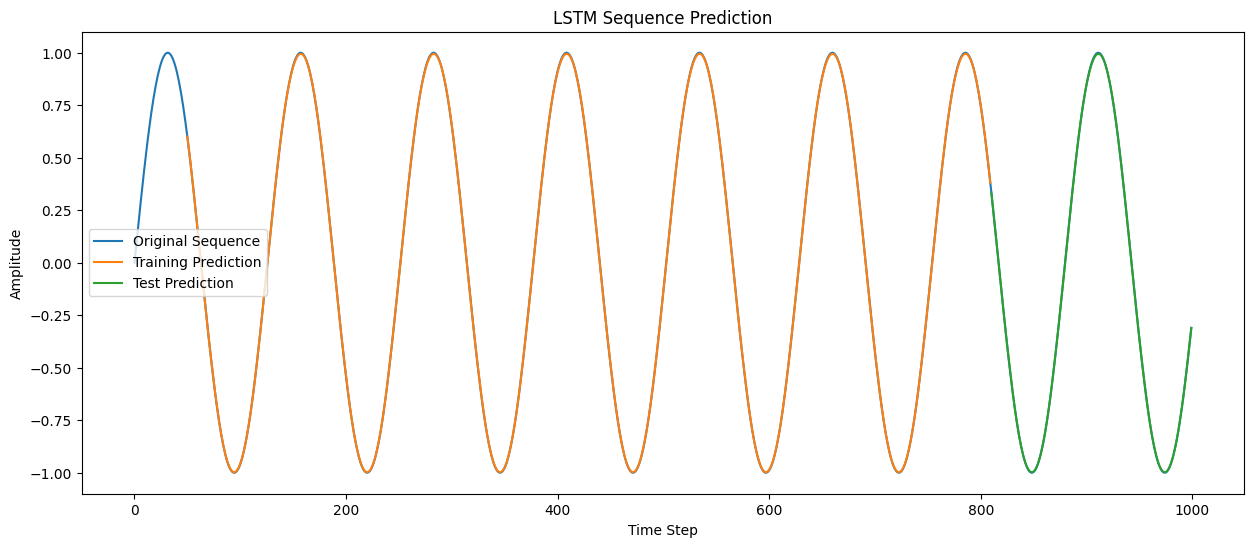

Prediction for the next 10 steps based on the last known sequence:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[-0.26349488 -0.21583447 -0.16780898 -0.11955751 -0.07123883 -0.02295088
  0.02511731  0.07285734  0.12026149  0.1671428 ]


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# 1. Generate synthetic sequence data (e.g., a sine wave)
def generate_sequence(length=1000, freq=0.05):
    time = np.arange(length)
    amplitude = np.sin(time * freq)
    return amplitude

sequence = generate_sequence()

# 2. Prepare data for LSTM
def create_dataset(sequence, look_back=1):
    X, y = [], []
    for i in range(len(sequence) - look_back):
        X.append(sequence[i:(i + look_back)])
        y.append(sequence[i + look_back])
    return np.array(X), np.array(y)

look_back = 50 # How many previous time steps to consider
X, y = create_dataset(sequence, look_back)

# Reshape input to be [samples, time_steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

# 3. Define a simple LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(look_back, 1)))
model.add(Dense(1))

# 4. Compile and train the model
model.compile(optimizer='adam', loss='mse')
print("\nTraining the LSTM model...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

print("Model training complete.\n")

# 5. Make predictions and visualize results
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Shift test predictions for plotting
test_predict_plot = np.empty_like(sequence)
test_predict_plot[:] = np.nan
test_predict_plot[len(train_predict) + look_back : len(sequence)] = test_predict.flatten()

plt.figure(figsize=(15, 6))
plt.plot(sequence, label='Original Sequence')
plt.plot(np.arange(look_back, len(train_predict) + look_back), train_predict.flatten(), label='Training Prediction')
plt.plot(test_predict_plot, label='Test Prediction')
plt.title('LSTM Sequence Prediction')
plt.xlabel('Time Step')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

print("Prediction for the next 10 steps based on the last known sequence:")
last_sequence = sequence[-look_back:]
future_predictions = []
current_input = last_sequence.reshape(1, look_back, 1)

for _ in range(10):
    next_prediction = model.predict(current_input)[0, 0]
    future_predictions.append(next_prediction)
    # Update input sequence: remove first element, add new prediction
    current_input = np.append(current_input[:, 1:, :], [[[next_prediction]]], axis=1)

print(np.array(future_predictions))